In [1]:
!pip install torch torchvision opencv-python scikit-image numpy


In [2]:
import cv2
import numpy as np
import os
import torch
from torchvision import datasets, transforms
from skimage.exposure import match_histograms


In [3]:
transform = transforms.ToTensor()

dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [00:02<00:00, 84.1MB/s]


In [4]:
# Take one image as Site-A reference
ref_img_tensor, _ = dataset[0]

# Convert tensor → OpenCV format
reference_img = (ref_img_tensor.permute(1,2,0).numpy() * 255).astype(np.uint8)


In [5]:
site_b_images = []

for i in range(1, 6):  # take 5 images
    img_tensor, _ = dataset[i]
    img_np = (img_tensor.permute(1,2,0).numpy() * 255).astype(np.uint8)
    site_b_images.append(img_np)


In [6]:
def preprocess_for_classifier(img, ref_img):
    # Resize to match reference
    img = cv2.resize(img, (ref_img.shape[1], ref_img.shape[0]))

    # LIGHTING STABILIZATION (Domain Adaptation)
    img_stable_light = match_histograms(img, ref_img, channel_axis=-1)

    # FEATURE ENHANCEMENT
    gray = cv2.cvtColor(img_stable_light.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    return enhanced


In [7]:
processed_dataset = []

for idx, img in enumerate(site_b_images):
    processed = preprocess_for_classifier(img, reference_img)
    processed_dataset.append(processed)

    # Save output to verify visually
    cv2.imwrite(f"stabilized_cifar_{idx}.png", processed)

print(f"Successfully processed {len(processed_dataset)} images.")


Successfully processed 5 images.


In [8]:
import matplotlib.pyplot as plt


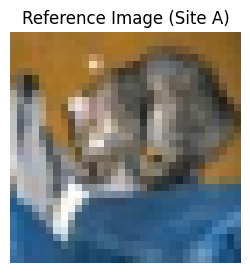

In [9]:
plt.figure(figsize=(3,3))
plt.imshow(reference_img)
plt.title("Reference Image (Site A)")
plt.axis("off")
plt.show()


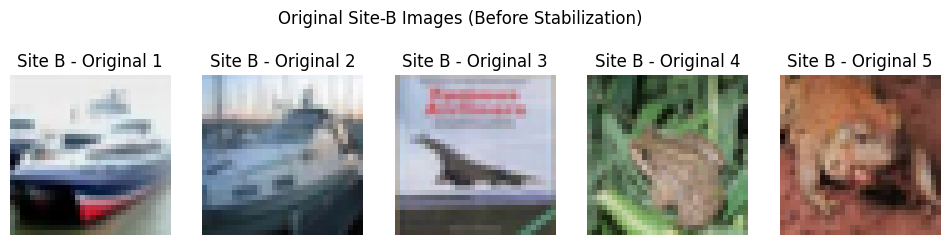

In [10]:
plt.figure(figsize=(12,3))

for i, img in enumerate(site_b_images):
    plt.subplot(1, len(site_b_images), i+1)
    plt.imshow(img)
    plt.title(f"Site B - Original {i+1}")
    plt.axis("off")

plt.suptitle("Original Site-B Images (Before Stabilization)")
plt.show()


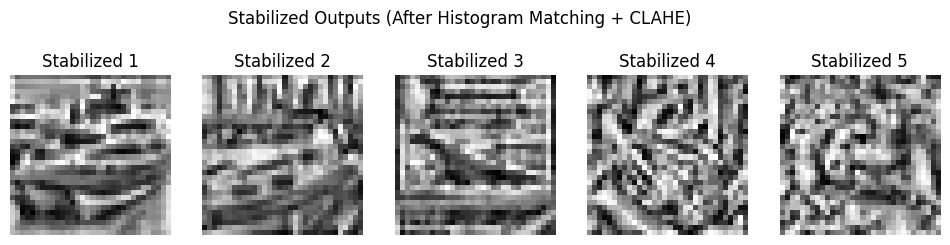

In [11]:
plt.figure(figsize=(12,3))

for i, img in enumerate(processed_dataset):
    plt.subplot(1, len(processed_dataset), i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Stabilized {i+1}")
    plt.axis("off")

plt.suptitle("Stabilized Outputs (After Histogram Matching + CLAHE)")
plt.show()
